# Notebook 07: Genre Performance Across Platforms

## Research Question 5

**How does the performance of video game genres vary across different platforms?**

## Objective

This notebook examines how video game genres perform across gaming platforms.

Rather than evaluating genres or platforms independently, the analysis focuses on the relationship between them. This helps identify which genre-platform combinations generated the strongest sales and whether certain genres performed particularly well on specific platforms.

The analysis will consider both total global sales and the number of games released. Average sales per game will also be examined so that combinations with large game libraries are not automatically treated as the strongest performers.

## Analysis Overview

This notebook will examine:

1. The number of games released for each genre-platform combination
2. Total global sales by genre and platform
3. Average global sales per game
4. The strongest genre-platform combinations
5. Genre performance across selected major platforms
6. The balance between release volume and sales performance

The notebook will conclude with a brief interpretation of the main findings and how they contribute to the broader video game sales analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [2]:
candidate_paths = [
    Path("../../data/processed/video_game_sales_cleaned.csv"),
    Path("../data/processed/video_game_sales_cleaned.csv"),
    Path("data/processed/video_game_sales_cleaned.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find video_game_sales_cleaned.csv. "
        "Update candidate_paths to match the notebook's location."
    )

df = pd.read_csv(data_path)

print(f"Loaded: {data_path.resolve()}")
print(f"Dataset shape: {df.shape}")
df.head()

Loaded: C:\Users\tyler\OneDrive\Desktop\26projects\data_an\data-analysis-on-the-videogame-industry\data\processed\video_game_sales_cleaned.csv
Dataset shape: (16287, 19)


,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.501450,0.350737,0.045564,0.102248,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.722664,0.088966,0.169235,0.019135,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.442367,0.359475,0.105777,0.092381,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.477273,0.333636,0.099394,0.089697,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.359146,0.283301,0.325685,0.031867,North America


In [3]:
analysis_df = df[
    ["name", "platform", "genre", "global_sales"]
].copy()

analysis_df = analysis_df.dropna(
    subset=["platform", "genre", "global_sales"]
)

print(f"Analysis dataset shape: {analysis_df.shape}")

analysis_df.head()

Analysis dataset shape: (16287, 4)


,name,platform,genre,global_sales
0,Wii Sports,Wii,Sports,82.74
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.82
3,Wii Sports Resort,Wii,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37


In [4]:
print(analysis_df.dtypes)

print(f"\nUnique platforms: {analysis_df['platform'].nunique()}")
print(f"Unique genres: {analysis_df['genre'].nunique()}")

name                str
platform            str
genre               str
global_sales    float64
dtype: object

Unique platforms: 31
Unique genres: 12


In [5]:
genre_platform_summary = (
    analysis_df
    .groupby(["platform", "genre"])
    .agg(
        game_count=("name", "count"),
        total_global_sales=("global_sales", "sum"),
        average_global_sales=("global_sales", "mean"),
        median_global_sales=("global_sales", "median")
    )
    .reset_index()
)

# Round sales values for readability
sales_columns = [
    "total_global_sales",
    "average_global_sales",
    "median_global_sales"
]

genre_platform_summary[sales_columns] = (
    genre_platform_summary[sales_columns].round(2)
)

genre_platform_summary.head(10)

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
0,2600,Action,55,26.39,0.48,0.38
1,2600,Adventure,1,0.40,0.40,0.40
2,2600,Fighting,1,0.77,0.77,0.77
3,2600,Misc,5,3.58,0.72,0.87
4,2600,Platform,9,13.27,1.47,1.10
5,2600,Puzzle,8,13.65,1.71,0.68
6,2600,Racing,4,2.32,0.58,0.44
7,2600,Shooter,22,22.97,1.04,0.75
8,2600,Simulation,1,0.45,0.45,0.45
9,2600,Sports,10,2.77,0.28,0.24


In [6]:
# Keep combinations with enough games for a more reliable comparison
minimum_games = 10

reliable_combinations = genre_platform_summary[
    genre_platform_summary["game_count"] >= minimum_games
].copy()

print(f"Genre-platform combinations with at least {minimum_games} games:")
print(reliable_combinations.shape[0])

Genre-platform combinations with at least 10 games:
207


In [7]:
top_total_sales = (
    reliable_combinations
    .sort_values("total_global_sales", ascending=False)
    .head(15)
)

top_total_sales

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
153,PS3,Action,373,304.02,0.82,0.32
244,Wii,Sports,256,289.95,1.13,0.23
266,X360,Shooter,197,277.23,1.41,0.41
141,PS2,Action,345,272.43,0.79,0.36
151,PS2,Sports,391,262.64,0.67,0.31
258,X360,Action,318,239.67,0.75,0.30
237,Wii,Misc,272,217.43,0.80,0.24
161,PS3,Shooter,155,195.80,1.26,0.57
147,PS2,Racing,212,154.21,0.73,0.26
37,DS,Misc,389,137.67,0.35,0.10


In [8]:
top_average_sales = (
    reliable_combinations
    .sort_values("average_global_sales", ascending=False)
    .head(15)
)

top_average_sales

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
52,GB,Role-Playing,21,88.24,4.20,0.76
108,NES,Platform,28,95.78,3.42,1.18
50,GB,Puzzle,15,47.47,3.16,1.15
49,GB,Platform,18,53.88,2.99,2.20
222,SNES,Platform,26,65.65,2.53,0.60
173,PS4,Shooter,34,75.32,2.22,1.26
104,NES,Action,13,28.75,2.21,1.64
113,NES,Sports,14,26.85,1.92,2.05
111,NES,Role-Playing,11,18.78,1.71,1.25
238,Wii,Platform,57,90.68,1.59,0.33


In [9]:
top_game_count = (
    reliable_combinations
    .sort_values("game_count", ascending=False)
    .head(15)
)

top_game_count

,platform,genre,game_count,total_global_sales,average_global_sales,median_global_sales
151,PS2,Sports,391,262.64,0.67,0.31
37,DS,Misc,389,137.67,0.35,0.10
153,PS3,Action,373,304.02,0.82,0.32
141,PS2,Action,345,272.43,0.79,0.36
34,DS,Action,335,114.16,0.34,0.12
258,X360,Action,318,239.67,0.75,0.30
43,DS,Simulation,279,131.36,0.47,0.12
237,Wii,Misc,272,217.43,0.80,0.24
244,Wii,Sports,256,289.95,1.13,0.23
35,DS,Adventure,238,47.15,0.20,0.08


### Top Genre–Platform Combinations by Total Global Sales

The following chart shows the genre-platform combinations that generated the greatest total global sales.

This measure reflects overall commercial contribution, but it may favour combinations with a large number of game releases.

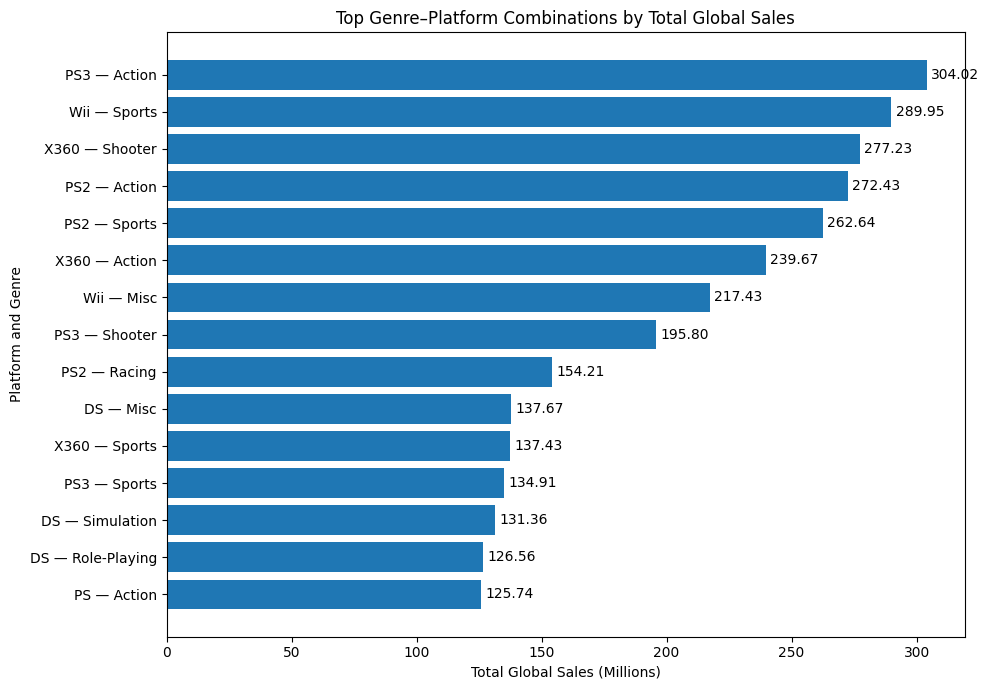

In [ ]:
top_total_sales = top_total_sales.copy()

top_total_sales["genre_platform"] = (
    top_total_sales["platform"]
    + " — "
    + top_total_sales["genre"]
)

plot_data = top_total_sales.sort_values(
    "total_global_sales",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_data["genre_platform"],
    plot_data["total_global_sales"]
)

plt.bar_label(bars, fmt="%.2f", padding=3)

plt.title("Top Genre–Platform Combinations by Total Global Sales")
plt.xlabel("Total Global Sales (Millions)")
plt.ylabel("Platform and Genre")

plt.tight_layout()
plt.show()